In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import time
import scienceplots
plt.style.use(['science','grid'])

### Simulate the stifness coefficients as lognormal random fields

In [2]:
#plotting utility function
def pcolor_plot(AX, X, Y, C, title,colormap="viridis",set_axis = 'off',**kwargs):
    ## plot the pcolor plot of the given data C on the given axis AX with the given title and optional colorbar limits cmin and cmax
    if len(kwargs) == 0:
        im = AX.pcolor(X, Y, C, cmap=colormap,shading='auto')
    else:
        cmin = kwargs["cmin"]
        cmax = kwargs["cmax"]
        im = AX.pcolor(X, Y, C, cmap=colormap, vmin=cmin, vmax=cmax,shading='auto')
    AX.set_aspect("equal", "box")
    AX.axis("off")
    AX.set_title(title, fontsize=14)
    return im

## Implementation of the PINN-PC framework

In [ ]:
# The code has been tested with both JAX and PyTorch backends. It should work with TensorFlow/Paddle as well but has not been tested.
# JAX is recommended for higher computational performance (x10-x20 faster than PyTorch in our implementation).
import deepxde as dde
import jax.numpy as jnp

# Define functions
sin = dde.backend.sin
cos = dde.backend.cos
stack = dde.backend.stack

net_type = ["spinn","pinn"][0]
Lmax = 100.0
pstress = 0.1

C11param = [1.55, 0.129, 20.18, 16.6]   # = [ mu, sigma , bx, by] 
C33param = [0.316, 0.027, 20.86, 15.08]

lmbd = C11param[0] - 2*C33param[0]
mu = C33param[0]

E = 9*mu*(lmbd + mu)/(3*lmbd + 3*mu)
nu = lmbd/(lmbd + 2*mu)

Exx_mean = pstress/E
Eyy_mean = -Exx_mean*nu

Exx_mean_fem = 0.09937324349011243
Eyy_mean_fem = -.05885460477883619

def transform_coords(x):
    """
    For SPINN, if the input x is provided as a list of 1D arrays (e.g., [X_coords, Y_coords]),
    this function creates a 2D meshgrid and stacks the results into a 2D coordinate array.
    """
    x_mesh = [x_.ravel() for x_ in jnp.meshgrid(jnp.atleast_1d(x[0].squeeze()), jnp.atleast_1d(x[1].squeeze()), indexing="ij")]
    return dde.backend.stack(x_mesh, axis=-1)

def solution_fn(x):
    if net_type == "spinn":
        x = transform_coords(x)
    Ux = Exx_mean_fem*x[:,0]
    Uy = Eyy_mean_fem*x[:,1]
    return np.stack([Ux,Uy],axis=1)

print(f"Ux_max/Ux_max_fem = {Exx_mean:0.4f}/{Exx_mean_fem:0.4f}")
print(f"Uy_min/Uy_min_fem = {Eyy_mean:0.4f}/{Eyy_mean_fem:0.4f}")
print(f"nu/nu_fem = {nu:0.4f}/{-Eyy_mean_fem/Exx_mean_fem:0.4f}")

Ux_max/Ux_max_fem = 0.1055/0.0994
Uy_min/Uy_min_fem = -0.0625/-0.0589
nu/nu_fem = 0.5923/0.5923


In [53]:
geom = dde.geometry.Rectangle([0, 0], [Lmax, Lmax])
BC_type = ["hard", "soft"][0]
coord_normalization = True
# x_max = 1.0 if coord_normalization else Lmax
num_bc_points = 25

bc_linspace = np.linspace(0, Lmax, num_bc_points).reshape(-1,1)
if net_type != "spinn":
    bc_0 = np.zeros_like(bc_linspace)
    bc_Lmax = Lmax*np.ones_like(bc_linspace)
else:
    bc_0 = np.array([0]).reshape(-1,1)
    bc_Lmax = np.array([Lmax]).reshape(-1,1)

bc_point_left = [bc_0, bc_linspace]
bc_point_right = [bc_Lmax, bc_linspace]
bc_point_bottom = [bc_linspace, bc_0]
bc_point_top = [bc_linspace, bc_Lmax]

if net_type != "spinn":
    bc_point_left = np.hstack(bc_point_left)
    bc_point_right = np.hstack(bc_point_right)
    bc_point_bottom = np.hstack(bc_point_bottom)
    bc_point_top = np.hstack(bc_point_top)

bc_point_all = [bc_point_left, bc_point_right, bc_point_bottom, bc_point_top]

# Soft Boundary Conditions
def S_from_output(x, f,X):
    if net_type == "spinn":
        x = transform_coords(x)
    E_xx = dde.grad.jacobian(f, x, i=0, j=0)[0]
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)[0]
    E_xy = 0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0])

    S_xx = E_xx * (2 * mu + lmbd) + E_yy * lmbd
    S_yy = E_yy * (2 * mu + lmbd) + E_xx * lmbd
    S_xy = E_xy * 2 * mu

    return stack((S_xx, S_yy, S_xy), axis=1)

ux_left_bc = dde.PointSetOperatorBC(bc_point_left,0,lambda x, f, X: f[:, 0])
uy_bottom_bc = dde.PointSetOperatorBC(bc_point_bottom,0,lambda x, f, X: f[:, 1])
sxx_right_bc = dde.PointSetOperatorBC(bc_point_right,0,lambda x, f, X: S_from_output(x, f, X)[:, 0:1]-pstress)
syy_top_bc = dde.PointSetOperatorBC(bc_point_top,0,lambda x, f, X: S_from_output(x, f, X)[:, 1:2])
sxy_bc = [dde.PointSetOperatorBC(bc_point,0,lambda x, f, X: S_from_output(x, f, X)[:, 2]) for bc_point in bc_point_all]

bcs = [ux_left_bc, uy_bottom_bc] if BC_type == "soft" else []
bcs += [sxx_right_bc,syy_top_bc]
bcs += sxy_bc

# Hard Boundary Conditions
def hard_BC(x, f):
    if isinstance(x, list) and net_type == "spinn":
        x = transform_coords(x)
    Ux = f[:, 0] * x[:, 0] 
    Uy = f[:, 1] * x[:, 1] 
    return stack((Ux, Uy), axis=1)

def pde(x, f):
    if net_type == "spinn":
        x = transform_coords(x)
    E_xx = dde.grad.jacobian(f, x, i=0, j=0)
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)
    E_xy = (0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0]), lambda x: 0.5 * (dde.grad.jacobian(f, x.reshape(1,-1), i=0, j=1)[1](x) + dde.grad.jacobian(f, x.reshape(1,-1), i=1, j=0)[1](x))) 

    S_xx = (E_xx[0] * (2 * mu + lmbd) + E_yy[0] * lmbd, lambda x: E_xx[1](x) * (2 * mu + lmbd) + E_yy[1](x) * lmbd)
    S_yy = (E_yy[0] * (2 * mu + lmbd) + E_xx[0] * lmbd, lambda x: E_yy[1](x) * (2 * mu + lmbd) + E_xx[1](x) * lmbd)
    S_xy = (E_xy[0] * 2 * mu, lambda x: E_xy[1](x) * 2 * mu)

    Sxx_x = dde.grad.jacobian(S_xx, x, i=0, j=0)[0]
    Syy_y = dde.grad.jacobian(S_yy, x, i=0, j=1)[0]
    Sxy_x = dde.grad.jacobian(S_xy, x, i=0, j=0)[0]
    Sxy_y = dde.grad.jacobian(S_xy, x, i=0, j=1)[0]

    momentum_x = Sxx_x + Sxy_y
    momentum_y = Sxy_x + Syy_y

    return [momentum_x, momentum_y]

In [54]:
data = dde.data.PDE(
    geom,
    pde,
    bcs,
    num_domain=1000 if net_type == "spinn" else 500,
    num_boundary=0,
    solution=solution_fn,
    num_test=100,
    is_SPINN=(net_type == "spinn"),
)

activation = "tanh"
initializer = "Glorot uniform"
if net_type == "spinn":
    layers = [2] + [32] * 3 + [2]
    net = dde.nn.SPINN(layers, activation, initializer)
else:
    layers = [2, [40] * 2, [40] * 2, [40] * 2, [40] * 2, 2]
    net = dde.nn.PFNN(layers, activation, initializer)


def input_scaling(x):
    """
    Scale the input coordinates to the range [0, 1].
    """
    if isinstance(x, list):
        return [x_el / Lmax for x_el in x]
    else:
        return x / Lmax
    
if BC_type == "hard":
    net.apply_output_transform(hard_BC)
if coord_normalization:
    net.apply_feature_transform(input_scaling)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"], loss_weights=[1]*8)

Compiling model...
'compile' took 0.072950 s



/home/dbey/miniconda3/envs/jax/lib/python3.12/site-packages/skopt/space/space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: Real.__init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/home/dbey/miniconda3/envs/jax/lib/python3.12/site-packages/skopt/space/space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: Real.__init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/home/dbey/miniconda3/envs/jax/lib/python3.12/site-packages/skopt/space/space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred t

In [55]:
from jax.flatten_util import ravel_pytree
import jax

X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
    
def loss_function(params,comp=0,inputs=[bc_point_right]+[bc_point_top]+bc_point_all+[X_input]):
    return model.outputs_losses_train(params, inputs, None)[1][comp]

n_loss = len(model.loss_weights)

def calc_loss_weights(model):
    loss_grads = [1]*n_loss

    for i in range(n_loss):
        grad_fn = jax.grad(lambda params,comp=i: loss_function(params,comp))
        grads = grad_fn(model.params)[0]
        flattened_grad = ravel_pytree(list(grads.values())[0])[0]
        loss_grads[i] = jnp.linalg.norm(flattened_grad)

    loss_grads = jnp.array(loss_grads)
    loss_weights_grads = jnp.sum(loss_grads)/loss_grads # Caution: ad-hoc sqrt
    return loss_weights_grads, loss_grads

loss_weights_grads, loss_grads = calc_loss_weights(model)
new_loss_weights = [w * g for w, g in zip(model.loss_weights, loss_weights_grads)]
model.compile("adam", lr=0.001, metrics=["l2 relative error"],
              loss_weights=new_loss_weights)

Compiling model...
'compile' took 0.106201 s



In [56]:
losshistory, train_state = model.train(iterations=5000, display_every=200)

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric   
0         [1.11e+00, 1.07e+00, 1.03e+00, 1.59e+00, 2.61e+00, 1.96e+00, 7.22e-01, 2.57e+00]    [1.09e+00, 1.06e+00, 1.03e+00, 1.59e+00, 2.61e+00, 1.96e+00, 7.22e-01, 2.57e+00]    [4.48e+00]    
200       [4.03e-04, 1.33e-04, 9.23e-06, 4.73e-06, 2.95e-05, 1.61e-05, 3.97e-05, 1.75e-05]    [2.92e-04, 1.02e-04, 9.23e-06, 4.73e-06, 2.95e-05, 1.61e-05, 3.97e-05, 1.75e-05]    [3.51e-02]    
400       [1.37e-04, 3.12e-05, 2.60e-06, 8.42e-07, 1.04e-05, 1.69e-05, 3.35e-06, 2.01e-05]    [9.79e-05, 2.45e-05, 2.60e-06, 8.42e-07, 1.04e-05, 1.69e-05, 3.35e-06, 2.01e-05]    [2.18e-02]    
600       [4.35e-05, 8.72e-06, 1.66e-06, 2.66e-07, 6.52e-06, 6.74e-06, 1.44e-06, 9.27e-06]    [3.04e-05, 6.94e-06, 1.66e-06, 2.66e-07, 6.52e-06, 6.74e-06, 1.44e-06, 9.27e-06]    [1.92e-02]    
800       [1.59e

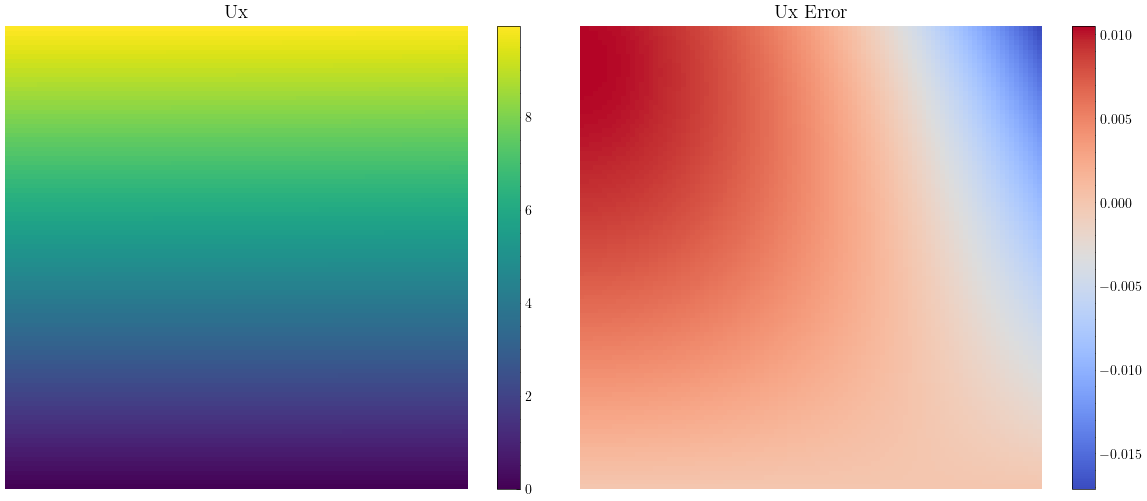

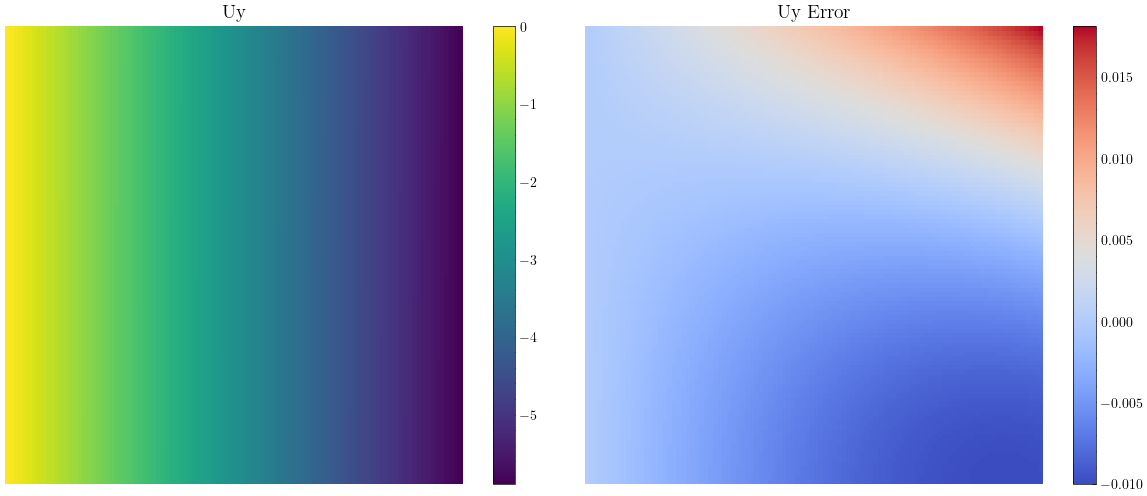

In [41]:
X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
Y_pred = model.predict([X_input])
Ux_pred = Y_pred[:, 0].reshape(X_mesh.shape)
Uy_pred = Y_pred[:, 1].reshape(X_mesh.shape)

Ux_true = solution_fn(X_input)[:,0].reshape(X_mesh.shape)
Uy_true = solution_fn(X_input)[:,1].reshape(X_mesh.shape)

fig,ax = plt.subplots(1, 2, figsize=(12, 5))
im = pcolor_plot(ax[0], X_mesh, Y_mesh, Ux_pred, "Ux")
fig.colorbar(im, ax=ax[0])
im = pcolor_plot(ax[1], X_mesh, Y_mesh, Ux_pred - Ux_true, "Ux Error",colormap="coolwarm")#,cmin=-0.1,cmax=0.1)
fig.colorbar(im, ax=ax[1])
fig.tight_layout()

fig,ax = plt.subplots(1, 2, figsize=(12, 5))
im = pcolor_plot(ax[0], X_mesh, Y_mesh, Uy_pred, "Uy")
fig.colorbar(im, ax=ax[0])
im = pcolor_plot(ax[1], X_mesh, Y_mesh, Uy_pred - Uy_true, "Uy Error",colormap="coolwarm")#,cmin=-0.1,cmax=0.1)
fig.colorbar(im, ax=ax[1])
fig.tight_layout()
